# Mini-project : Dream House

### Learning Objectives
> - Create labeled line, scatter, bar, and histogram plots.
> -  Combine multiple plots into one figure using subplots.
> -  Assemble a complete mini-notebook using NumPy, Pandas, and Matplotlib together.

## Story:
Natash and her husband Lucas are a married couple with 5 kids, theyve been working, investing, and saving their earnings to move into a comfortable new house. Emparcing in a deep and lengthy reasearch, they agreed upon picking an area in King County-Washington. Their goal is to find a house that is big enough for all the family members so each kid can have their own bedroom. The house also should have a garden so all the family can enjoy their home during weekends and vications. with a bidget of 300k dollars.


## Step 1 : Finding a good dataset and preparing it to help the family sort out their options

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### 1) Uploading the dataset

In [18]:
df = pd.read_csv("kc_house_data.csv")
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

(21613, 21)

### 2) Data preperations and cleaning

In [3]:

df.isnull().sum()          # The function returned 0 meaning there werent any missing values in the columns


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [4]:
df.duplicated().sum() # output: no duplicat rows


np.int64(0)

#### We then check for strange values to see if the data doesn't contain errors
> There might be houses with unusual data, Like a zero number of bedrooms, so we check the counts of bedrooms to ensure that we will only perform the calculations on a real house 

In [5]:
df['bedrooms'].value_counts()

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

**Here, we notice that some rows have 0 bedrooms and one column has 33 bedrooms. These data might be an error and even if they were just rare houses, they wouldnt be what a family of 7 people are looking for so we will remove them anyways.**

In [6]:
df[df['bedrooms'] == 33][
    ['price','bedrooms','bathrooms','sqft_living','sqft_lot']
]

df[df['bedrooms'] == 0][
    ['price','bedrooms','bathrooms','sqft_living','sqft_lot']
]

,price,bedrooms,bathrooms,sqft_living,sqft_lot
875,1100000.0,0,0.00,3064,4764
3119,380000.0,0,0.00,1470,979
3467,288000.0,0,1.50,1430,1650
4868,228000.0,0,1.00,390,5900
6994,1300000.0,0,0.00,4810,28008
8477,339950.0,0,2.50,2290,8319
8484,240000.0,0,2.50,1810,5669
9773,355000.0,0,0.00,2460,8049
9854,235000.0,0,0.00,1470,4800
12653,320000.0,0,2.50,1490,7111


### 3) Cleaning and execluding all the houses with suspecious data

In [7]:

houses = df.copy()                    # Copying data into a new dataframe to not affect the original dataset


houses = houses.drop_duplicates()     # Removeing duplicates

# Remove impossible bedrooms
houses = houses[
    (houses['bedrooms'] > 0) &
    (houses['bedrooms'] <= 10)
]

# Remove impossible prices
houses = houses[
    houses['price'] > 0
]

# Remove impossible living areas
houses = houses[
    houses['sqft_living'] > 0
]

In [8]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21598 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21598 non-null  int64  
 1   date           21598 non-null  object 
 2   price          21598 non-null  float64
 3   bedrooms       21598 non-null  int64  
 4   bathrooms      21598 non-null  float64
 5   sqft_living    21598 non-null  int64  
 6   sqft_lot       21598 non-null  int64  
 7   floors         21598 non-null  float64
 8   waterfront     21598 non-null  int64  
 9   view           21598 non-null  int64  
 10  condition      21598 non-null  int64  
 11  grade          21598 non-null  int64  
 12  sqft_above     21598 non-null  int64  
 13  sqft_basement  21598 non-null  int64  
 14  yr_built       21598 non-null  int64  
 15  yr_renovated   21598 non-null  int64  
 16  zipcode        21598 non-null  int64  
 17  lat            21598 non-null  float64
 18  long       

In [9]:
print(df.shape)
print(houses.shape)        # printing out the original df and the copy to see how many rows have been execluded

(21613, 21)
(21598, 21)


## Step 2: Filter the houses down to the ones that actually fit the family's budget and space needs.

Using NumPy to derive new features like total area and price per sqft.


### We are aiming to find a house that meets these requirements
- Budget: ≤ $300,000
- Suitable size for a family of 7:
    > - At least 7 bedrooms/rooms
    > - At least 3 bathrooms
- Has outdoor space( a garden)
    

In [ ]:
suitable_house = houses[
    (houses['price'] <= 300000) &
    (houses['bedrooms'] >= 5) &
    (houses['bathrooms'] >= 3) &
    (houses['sqft_lot'] > 700 )
].copy()
print("The number of houses that meet the requirements : " ,suitable_house.shape[0])



The number of houses that meet the requirements :  15


#### Among the 15 suitable houses, which ones are the best value and which characteristics make them more expensive?

 As the number of bedrooms goes up, the average price generally goes up too, more bedrooms usually means a bigger house. 



In [ ]:
# Average price for each number of bedrooms
suitable_house.groupby('bedrooms')['price'].mean()

bedrooms
5    282250.000000
6    276428.571429
Name: price, dtype: float64

We calculated the overall area of the estate, which is the summation of both the living areas and the yards (lots).
then seeing how more area affects the price



In [ ]:
suitable_house['Whole_area'] = suitable_house['sqft_living'] + suitable_house['sqft_lot']
suitable_house.groupby('Whole_area')['price'].mean()

Whole_area
7207     295000.0
7370     285000.0
8295     300000.0
8542     300000.0
8990     267500.0
9400     230000.0
9980     265000.0
10039    292050.0
10136    235000.0
11773    290000.0
11852    298450.0
12670    300000.0
12700    255000.0
14024    290000.0
Name: price, dtype: float64

In [ ]:
suitable_house['price_per_sqft'] = np.round(
    suitable_house['price'] / suitable_house['Whole_area'], 2
)
suitable_house[['price', 'Whole_area', 'price_per_sqft']].head(15)

,price,Whole_area,price_per_sqft
1160,267500.0,8990,29.76
1478,235000.0,10136,23.18
1926,255000.0,12700,20.08
2496,280000.0,11773,23.78
2497,300000.0,11773,25.48
4931,300000.0,8295,36.17
6320,295000.0,7207,40.93
8617,265000.0,9980,26.55
8914,290000.0,14024,20.68
9055,285000.0,7370,38.67


## Step 3 : Displaying the data and outcomes visually 

Visualizing the data is a great way to show the family their options in a clear understandable way. Here we displayed what characteristics affect the price of the residences.

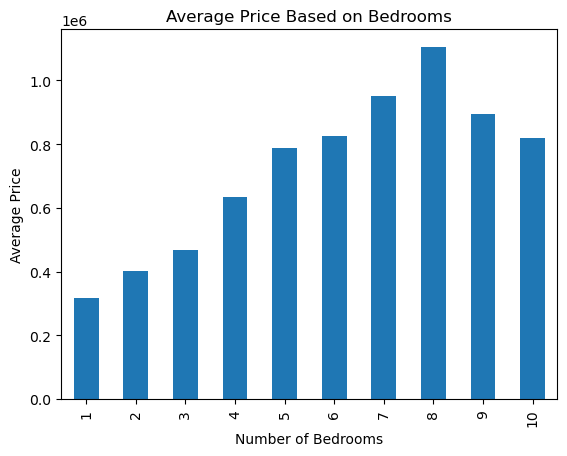

In [14]:
bedroom_prices = houses.groupby('bedrooms')['price'].mean()
bedroom_prices.plot(
    kind='bar'
)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.title("Average Price Based on Bedrooms")

plt.show()

#### What does this tell us about bedrooms and price?
> As the number of bedrooms goes up, the average price generally goes up too, which makes sense since more bedrooms usually means a bigger house.

**We do notice a small dip around 9-10 bedrooms, but this is probably because there are very few houses with that many bedrooms in the dataset, so the average isnt very reliable there.**


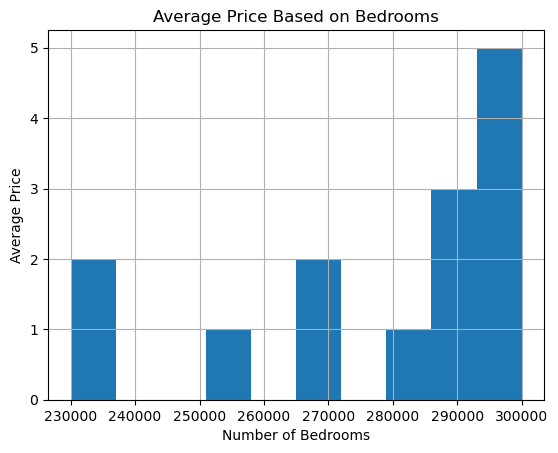

In [15]:
bedroom_prices = suitable_house.groupby('Whole_area')['price'].mean()
bedroom_prices.hist()

plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.title("Average Price Based on Bedrooms")

plt.show()

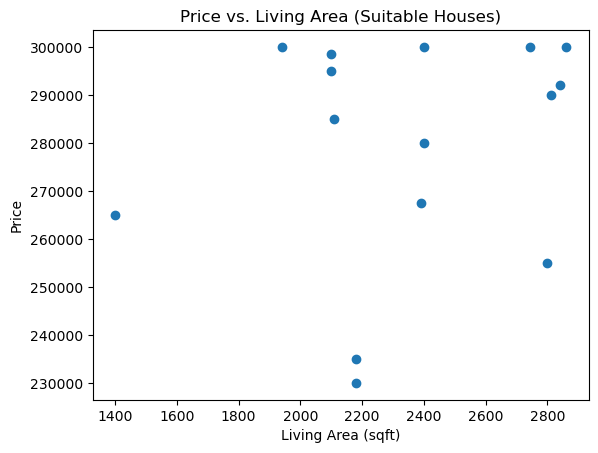

In [16]:
plt.scatter(suitable_house['sqft_living'], suitable_house['price'])
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Price vs. Living Area (Suitable Houses)")
plt.show()

#### Price vs living area for our suitable houses
> We plotted sqft_living against price to see if bigger homes cost more, even within our filtered budget-friendly houses.

**There is a clear positive relationship, as living area increases the price tends to increase too, but its not a perfect straight line since other things like lot size and condition affect the price as well.**


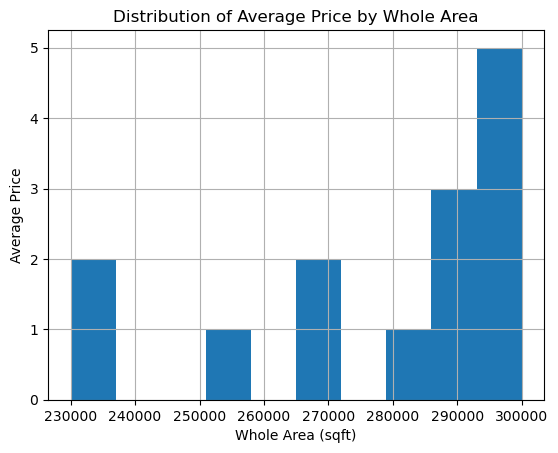

In [17]:
bedroom_prices = suitable_house.groupby('Whole_area')['price'].mean()
bedroom_prices.hist()

plt.xlabel("Whole Area (sqft)")
plt.ylabel("Average Price")
plt.title("Distribution of Average Price by Whole Area")
plt.show()

#### Exploring how Whole_area relates to price among the suitable houses
> Since we already filtered the houses to a 300k budget and a family-sized requirement, most of the "Whole_area" groups end up with average prices that are pretty close to each other and clustered near the top of our budget.

**This shows that within our suitable houses, area alone doesn't create huge price jumps, other factors like bathrooms or location are probably playing a role too.**


## Conclusion: Ranking the Suitable Houses by Price
> Out of the 15 houses that meet the family's requirements, here they are ranked from cheapest to most expensive, so Natasha and Lucas can start with the most affordable options first.

In [ ]:

cheapest_houses = suitable_house.sort_values('price', ascending=True)[['id', 'price']]
cheapest_houses